# Week 2 — Burn Window Climatology
**Fire Weather Windows · PNW Prescribed Fire Decision Support**

This notebook applies USFS burn window threshold logic to the processed RAWS historical dataset and computes climatological patterns. Outputs are clean DataFrames and visualizations that feed directly into the Week 3 forecast comparison and Week 4 Streamlit dashboard.

### Key questions answered here
1. Which stations have the most viable burn hours per year?
2. What months are peak window months across the PNW network?
3. How much station-to-station variation exists within the same week?
4. Are there consistent multi-day window clusters?

In [38]:
import sys, warnings
sys.path.insert(0, '../')   # make src importable from notebooks/
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

from src.analysis.burn_windows import (
    load_processed, hourly_flags, daily_windows,
    find_window_clusters, summarise_flags
)
from src.analysis.climatology import (
    monthly_climatology, weekly_climatology, seasonal_summary,
    station_annual_summary, peak_season_by_station,
    cross_station_weekly_variation,
    station_month_heatmap, station_week_heatmap
)

# ---- style ----
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
FIRE_CMAP = 'YlOrRd'   # yellow → orange → red — intuitive for fire weather
COOL_CMAP = 'Blues'

OUT_DIR = Path('../data/processed/raws')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1 · Load Data and Apply Threshold Logic

In [39]:
CSV_PATH = '../data/processed/raws/raws_combined_20250410_20260410.csv'

hourly = load_processed(CSV_PATH)
hourly.head(3)

  Columns found: ['station_id', 'datetime', 'temp_f', 'rh_pct', 'wind_speed_mph', 'wind_dir_deg', 'station_name', 'state', 'lat', 'lon']
  Columns after rename: ['station_id', 'datetime', 'temp_f', 'rh', 'wind_mph', 'wind_dir', 'station_name', 'state', 'lat', 'lon']
Loaded 129,794 records | 15 stations | 2025-04-10 → 2026-04-10


,station_id,datetime,temp_f,rh,wind_mph,wind_dir,station_name,state,lat,lon
0,ANEW1,2025-04-10 21:09:00,47.0,59.0,10.43,170.0,AENEAS,WA,48.74325,-119.62247
1,ANEW1,2025-04-10 22:09:00,46.0,61.0,13.03,154.0,AENEAS,WA,48.74325,-119.62247
2,ANEW1,2025-04-10 23:09:00,44.0,70.0,14.77,173.0,AENEAS,WA,48.74325,-119.62247


In [40]:
# Apply USFS threshold logic to every hour
# Thresholds: RH 25–55%, wind 5–15 mph, temp < 90°F
flags = hourly_flags(hourly)

print('Threshold flag columns added:')
print(flags[['station_id','datetime','temp_f','rh','wind_mph',
             'rh_ok','wind_ok','temp_ok','burn_window']].head(10).to_string(index=False))

Threshold flag columns added:
station_id            datetime  temp_f   rh  wind_mph  rh_ok  wind_ok  temp_ok  burn_window
     ANEW1 2025-04-10 21:09:00    47.0 59.0     10.43  False     True     True        False
     ANEW1 2025-04-10 22:09:00    46.0 61.0     13.03  False     True     True        False
     ANEW1 2025-04-10 23:09:00    44.0 70.0     14.77  False     True     True        False
     ANEW1 2025-04-11 00:09:00    45.0 70.0     14.77  False     True     True        False
     ANEW1 2025-04-11 01:09:00    45.0 70.0     13.03  False     True     True        False
     ANEW1 2025-04-11 02:09:00    42.0 79.0     16.51  False    False     True        False
     ANEW1 2025-04-11 03:09:00    40.0 85.0     12.17  False     True     True        False
     ANEW1 2025-04-11 04:09:00    41.0 72.0     13.03  False     True     True        False
     ANEW1 2025-04-11 05:09:00    40.0 66.0      9.56  False     True     True        False
     ANEW1 2025-04-11 06:09:00    39.0 57.0     11

In [41]:
# Aggregate to daily burn window scores
daily = daily_windows(flags)

print(f'Daily records: {len(daily):,}')
print(f'Stations: {daily.station_id.nunique()}')
print(f'Date range: {daily.date.min().date()} → {daily.date.max().date()}')
print('\nWindow quality distribution:')
print(daily.window_quality.value_counts())

Daily records: 5,455
Stations: 15
Date range: 2025-04-10 → 2026-04-10

Window quality distribution:
window_quality
no_window            2805
full                 1056
partial               806
marginal              736
insufficient_data      52
Name: count, dtype: int64


In [42]:
# Save daily windows for downstream use (Week 3 forecast comparison)
daily.to_csv(OUT_DIR / 'daily_windows.csv', index=False)
print('Saved daily_windows.csv')

Saved daily_windows.csv


In [43]:
# Which variable is the most frequent limiting factor?
flag_summary = summarise_flags(flags)
print('Variable failure analysis (hours where that variable alone fails threshold):')
print(flag_summary.sort_values('pct_viable', ascending=False).to_string(index=False))

Variable failure analysis (hours where that variable alone fails threshold):
station_id  total_hours  burn_window_hours  rh_fail_hours  wind_fail_hours  temp_fail_hours  pct_viable
     ANEW1         8737               2353           5303             2963                1        26.9
     HIBW1         8735               1792           4906             4884              243        20.5
     GRFW1         8737               1773           5693             4023               23        20.3
     TT246         8731               1246           4726             6174              148        14.3
     WSRO3         8737               1128           5509             6638              376        12.9
     TPEO3         8738               1106           5667             6059               31        12.7
     DRYW1         8725               1036           5900             5314               61        11.9
     LBFO3         8735               1004           5634             5144               79

---
## 2 · Station Annual Summary
**Q: Which stations have the most viable burn hours per year?**

In [44]:
annual = station_annual_summary(daily)
annual.to_csv(OUT_DIR / 'station_annual_summary.csv', index=False)
annual

,station_id,total_days,viable_days,full_window_days,annual_window_hours,mean_window_hours,pct_viable_days,pct_full_days,peak_month,peak_season
0,HIBW1,364,266,157,1791,6.7,73.1,43.1,May,spring
1,TPEO3,364,260,74,1105,4.2,71.4,20.3,May,spring
2,TT246,364,245,98,1244,5.1,67.3,26.9,May,spring
3,WSRO3,364,241,75,1126,4.7,66.2,20.6,Jul,summer
4,ANEW1,364,237,165,2353,9.9,65.1,45.3,Jul,summer
5,GRFW1,364,227,146,1773,7.8,62.4,40.1,Jul,summer
6,DRYW1,364,184,73,1036,5.6,50.5,20.1,Jul,summer
7,MILW1,364,175,59,817,4.7,48.1,16.2,May,spring
8,LBFO3,364,174,60,1003,5.8,47.8,16.5,Mar,fall
9,PEFW1,364,163,64,922,5.7,44.8,17.6,Jul,summer


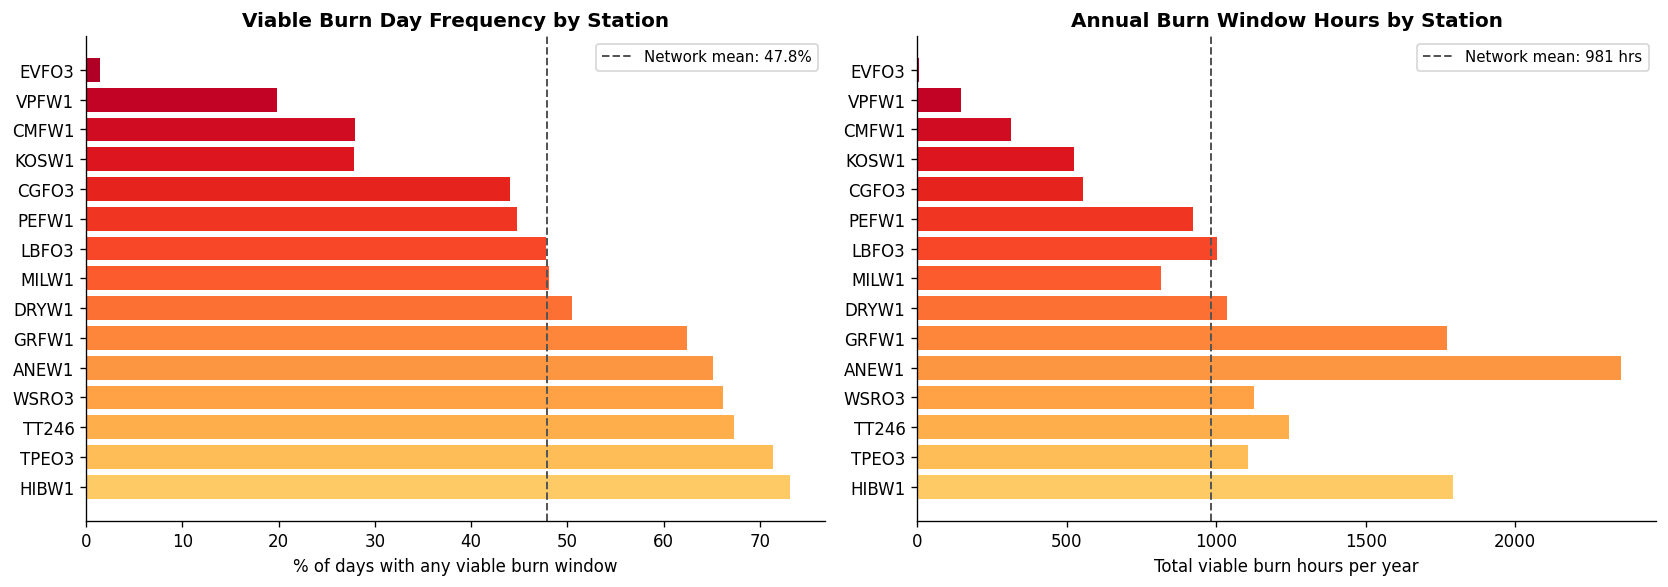

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: viable days per station ---
ax = axes[0]
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(annual)))
bars = ax.barh(annual['station_id'], annual['pct_viable_days'], color=colors)
ax.set_xlabel('% of days with any viable burn window')
ax.set_title('Viable Burn Day Frequency by Station', fontweight='bold')
ax.axvline(annual['pct_viable_days'].mean(), color='#555', lw=1.2, ls='--', label=f"Network mean: {annual['pct_viable_days'].mean():.1f}%")
ax.legend(fontsize=9)

# --- right: annual window hours ---
ax2 = axes[1]
bars2 = ax2.barh(annual['station_id'], annual['annual_window_hours'], color=colors)
ax2.set_xlabel('Total viable burn hours per year')
ax2.set_title('Annual Burn Window Hours by Station', fontweight='bold')
ax2.axvline(annual['annual_window_hours'].mean(), color='#555', lw=1.2, ls='--',
            label=f"Network mean: {annual['annual_window_hours'].mean():.0f} hrs")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_station_annual_summary.png', bbox_inches='tight')
plt.show()

---
## 3 · Monthly Climatology
**Q: What months are peak window months across the PNW?**

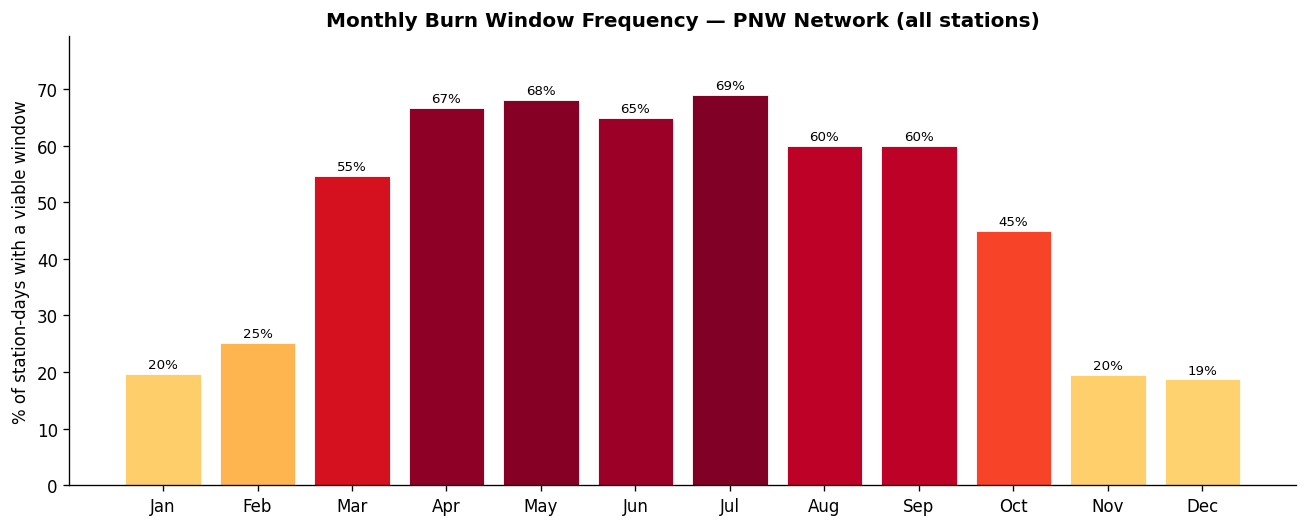

In [46]:
monthly = monthly_climatology(daily)
monthly.to_csv(OUT_DIR / 'climatology_monthly.csv', index=False)

# Network-wide monthly aggregation (all stations pooled)
net_monthly = (
    daily[daily['window_quality'] != 'insufficient_data']
    .groupby('month')
    .agg(
        viable_days=('any_window', 'sum'),
        total_days= ('any_window', 'count'),
    )
    .reset_index()
)
net_monthly['pct_viable'] = (net_monthly['viable_days'] / net_monthly['total_days'] * 100).round(1)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 4.5))
bar_colors = plt.cm.YlOrRd(net_monthly['pct_viable'] / net_monthly['pct_viable'].max())
ax.bar(net_monthly['month'], net_monthly['pct_viable'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('% of station-days with a viable window')
ax.set_title('Monthly Burn Window Frequency — PNW Network (all stations)', fontweight='bold')
ax.set_ylim(0, net_monthly['pct_viable'].max() * 1.15)
for i, row in net_monthly.iterrows():
    ax.text(row['month'], row['pct_viable'] + 0.5, f"{row['pct_viable']:.0f}%",
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_monthly_network.png', bbox_inches='tight')
plt.show()

---
## 4 · Station × Month Heatmap
The primary deliverable visualization — shows both the seasonal pattern and station-to-station variation simultaneously.

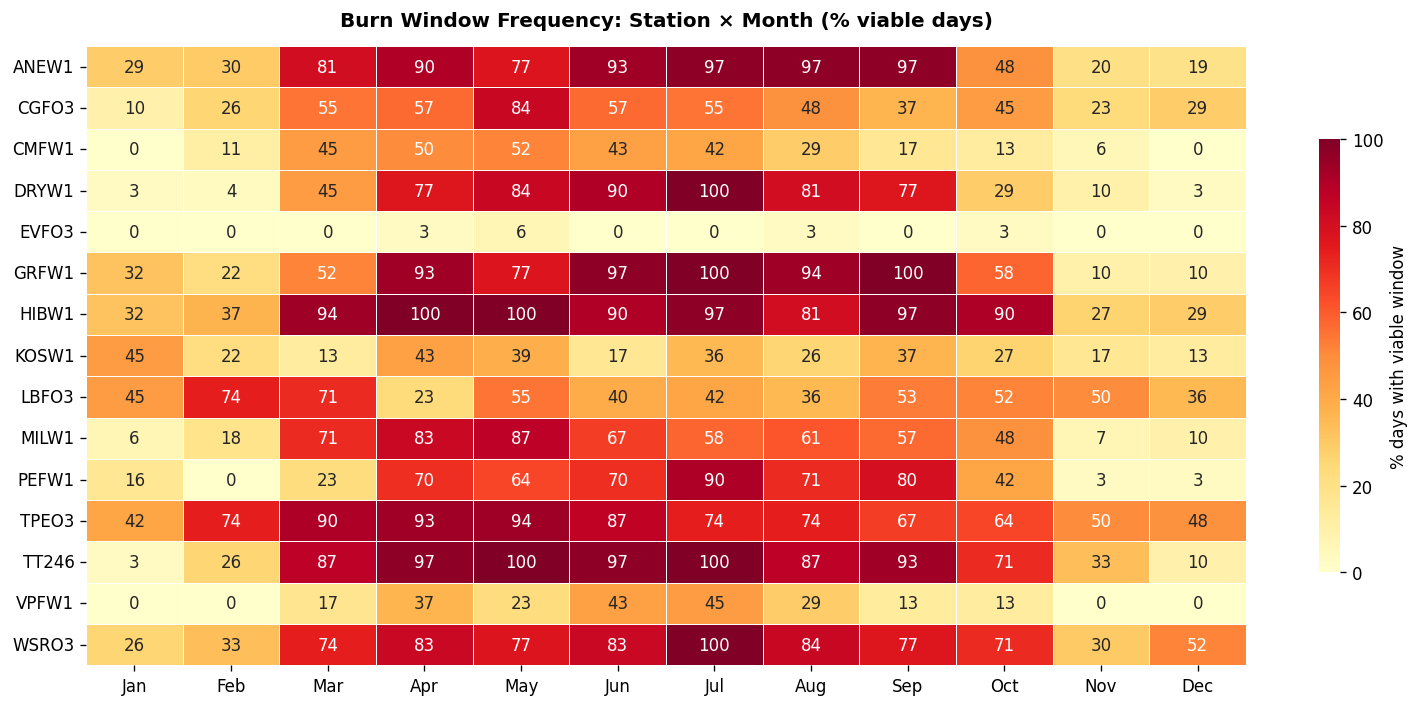

In [47]:
pivot = station_month_heatmap(daily, metric='pct_viable_days')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot,
    cmap=FIRE_CMAP,
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': '% days with viable window', 'shrink': 0.7},
    ax=ax,
    vmin=0,
)
ax.set_title('Burn Window Frequency: Station × Month (% viable days)', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_heatmap_station_month.png', bbox_inches='tight', dpi=150)
plt.show()

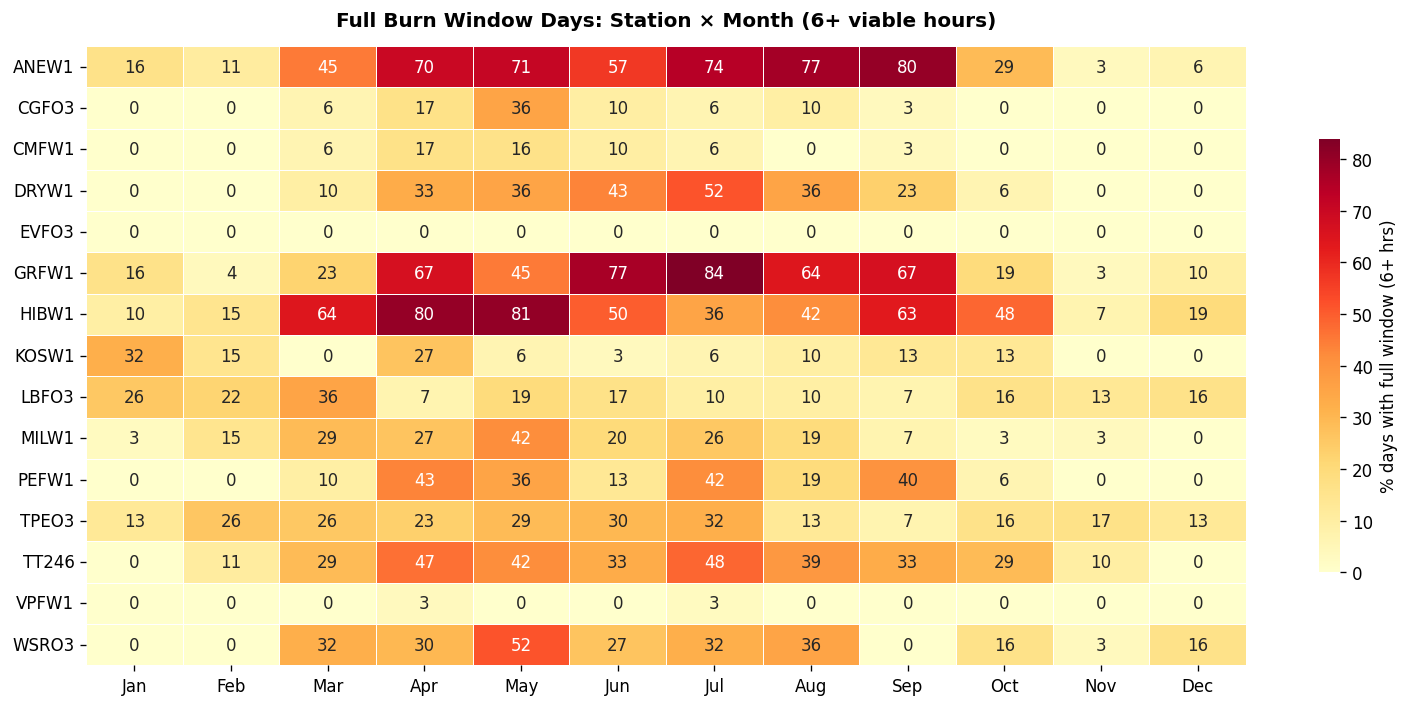

In [48]:
# Full-window days heatmap (6+ viable hours — operationally more useful)
pivot_full = station_month_heatmap(daily, metric='pct_full_days')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_full,
    cmap=FIRE_CMAP,
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': '% days with full window (6+ hrs)', 'shrink': 0.7},
    ax=ax,
    vmin=0,
)
ax.set_title('Full Burn Window Days: Station × Month (6+ viable hours)', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_heatmap_full_windows.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5 · Weekly Climatology & Cross-Station Variation
**Q: How much station-to-station variation exists within the same week?**

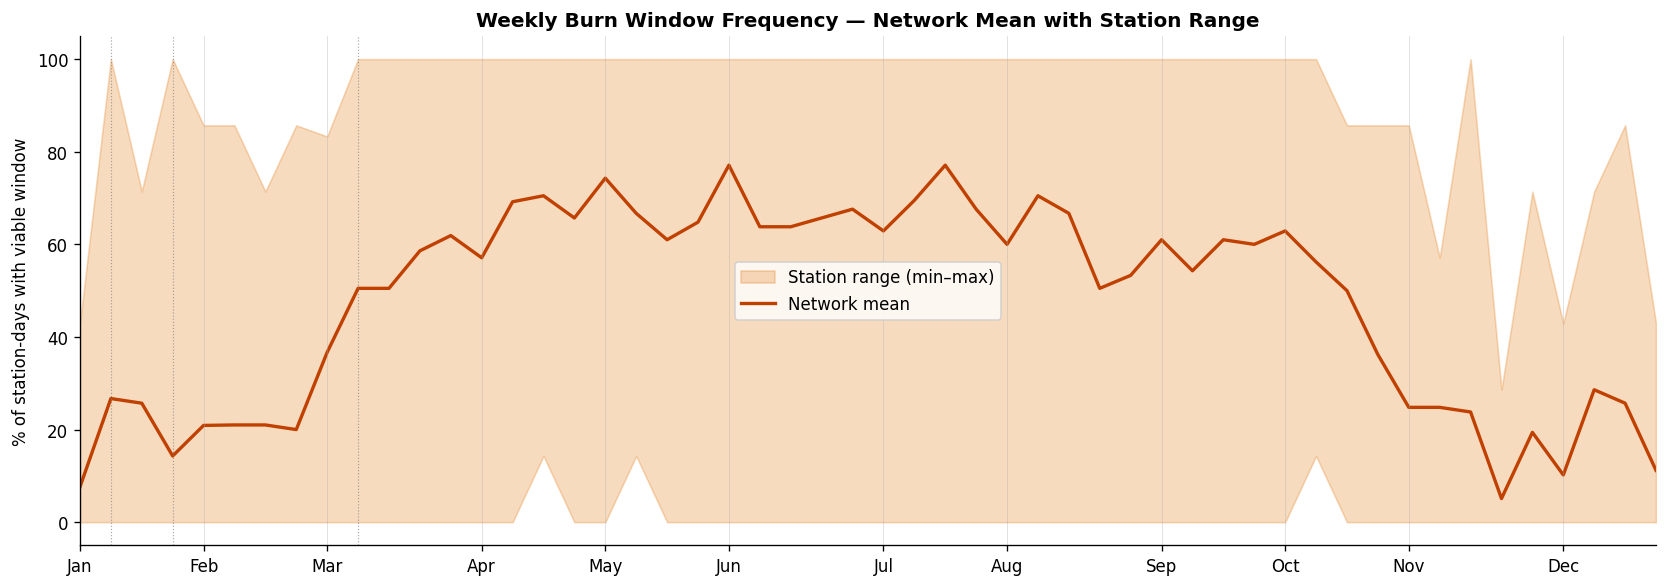


Highest inter-station variation weeks: weeks [2, 4, 10]
  → these are weeks where some stations are burnable and others aren't


In [49]:
weekly = weekly_climatology(daily)
weekly.to_csv(OUT_DIR / 'climatology_weekly.csv', index=False)

variation = cross_station_weekly_variation(daily)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    variation['week_of_year'],
    variation['min_viable_pct'],
    variation['max_viable_pct'],
    alpha=0.25, color='#e07000', label='Station range (min–max)'
)
ax.plot(variation['week_of_year'], variation['mean_viable_pct'],
        color='#c04000', lw=2, label='Network mean')

# annotate high-variation weeks
high_var = variation.nlargest(3, 'range_pct')
for _, row in high_var.iterrows():
    ax.axvline(row['week_of_year'], color='gray', lw=0.7, ls=':', alpha=0.7)

# month separator lines
month_week_starts = {1:1, 2:5, 3:9, 4:14, 5:18, 6:22, 7:27, 8:31, 9:36, 10:40, 11:44, 12:49}
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for m, w in month_week_starts.items():
    ax.axvline(w, color='#aaa', lw=0.5, ls='-', alpha=0.4)
ax.set_xticks(list(month_week_starts.values()))
ax.set_xticklabels(month_labels)

ax.set_xlabel('')
ax.set_ylabel('% of station-days with viable window')
ax.set_title('Weekly Burn Window Frequency — Network Mean with Station Range', fontweight='bold')
ax.legend()
ax.set_xlim(1, 52)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_weekly_variation.png', bbox_inches='tight')
plt.show()

print(f"\nHighest inter-station variation weeks: weeks {high_var['week_of_year'].tolist()}")
print(f"  → these are weeks where some stations are burnable and others aren't")

---
## 6 · Seasonal Summary & Peak Season by Station

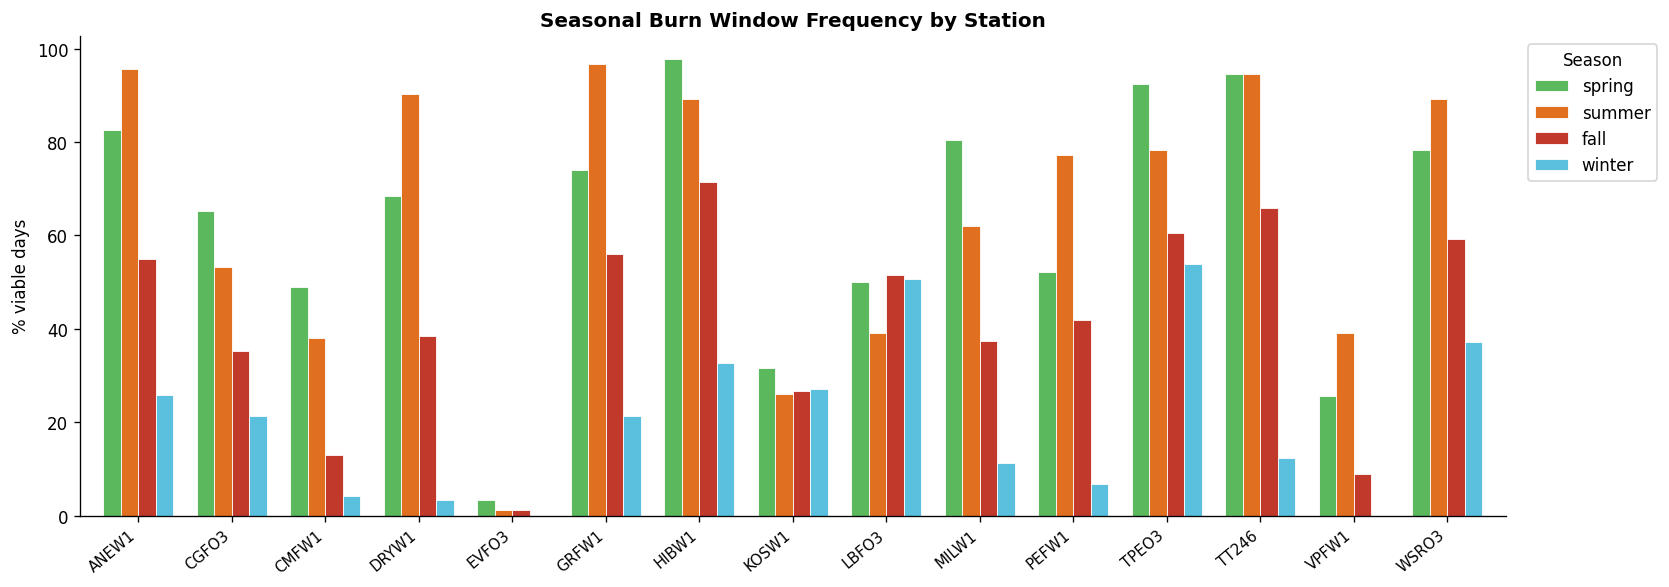

In [50]:
seasonal = seasonal_summary(daily)
seasonal.to_csv(OUT_DIR / 'climatology_seasonal.csv', index=False)

# pivot for grouped bar chart: stations × seasons
pivot_seasonal = seasonal.pivot(index='station_id', columns='season', values='pct_viable_days')
season_order = ['spring', 'summer', 'fall', 'winter']
pivot_seasonal = pivot_seasonal.reindex(columns=[s for s in season_order if s in pivot_seasonal.columns])

season_colors = {'spring': '#5cb85c', 'summer': '#e07020', 'fall': '#c0392b', 'winter': '#5bc0de'}

fig, ax = plt.subplots(figsize=(14, 5))
pivot_seasonal.plot(
    kind='bar',
    ax=ax,
    color=[season_colors.get(s, '#999') for s in pivot_seasonal.columns],
    edgecolor='white',
    linewidth=0.5,
    width=0.75,
)
ax.set_xlabel('')
ax.set_ylabel('% viable days')
ax.set_title('Seasonal Burn Window Frequency by Station', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.legend(title='Season', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_seasonal_by_station.png', bbox_inches='tight')
plt.show()

In [51]:
# Peak 4-week burn window period per station
peak = peak_season_by_station(daily)
peak.to_csv(OUT_DIR / 'peak_season_by_station.csv', index=False)
print('Peak 4-week burn window period by station:')
print(peak.to_string(index=False))

Peak 4-week burn window period by station:
station_id  peak_start_week  peak_end_week peak_month_range  mean_viable_pct_in_window
     ANEW1               26             29          Jun–Jul                      100.0
     GRFW1               15             18          Apr–May                      100.0
     HIBW1               12             15          Mar–Apr                      100.0
     TT246               15             18          Apr–May                      100.0
     WSRO3               28             31          Jul–Jul                      100.0
     DRYW1               22             25          May–Jun                       96.4
     TPEO3               15             18          Apr–May                       96.4
     MILW1               15             18          Apr–May                       92.8
     PEFW1               27             30          Jul–Jul                       89.3
     CGFO3               19             22          May–May                       85.7


---
## 7 · Per-Station Time Series with Burn Window Shading
Shows the full-year pattern with burn window hours overlaid — pick a few representative stations.

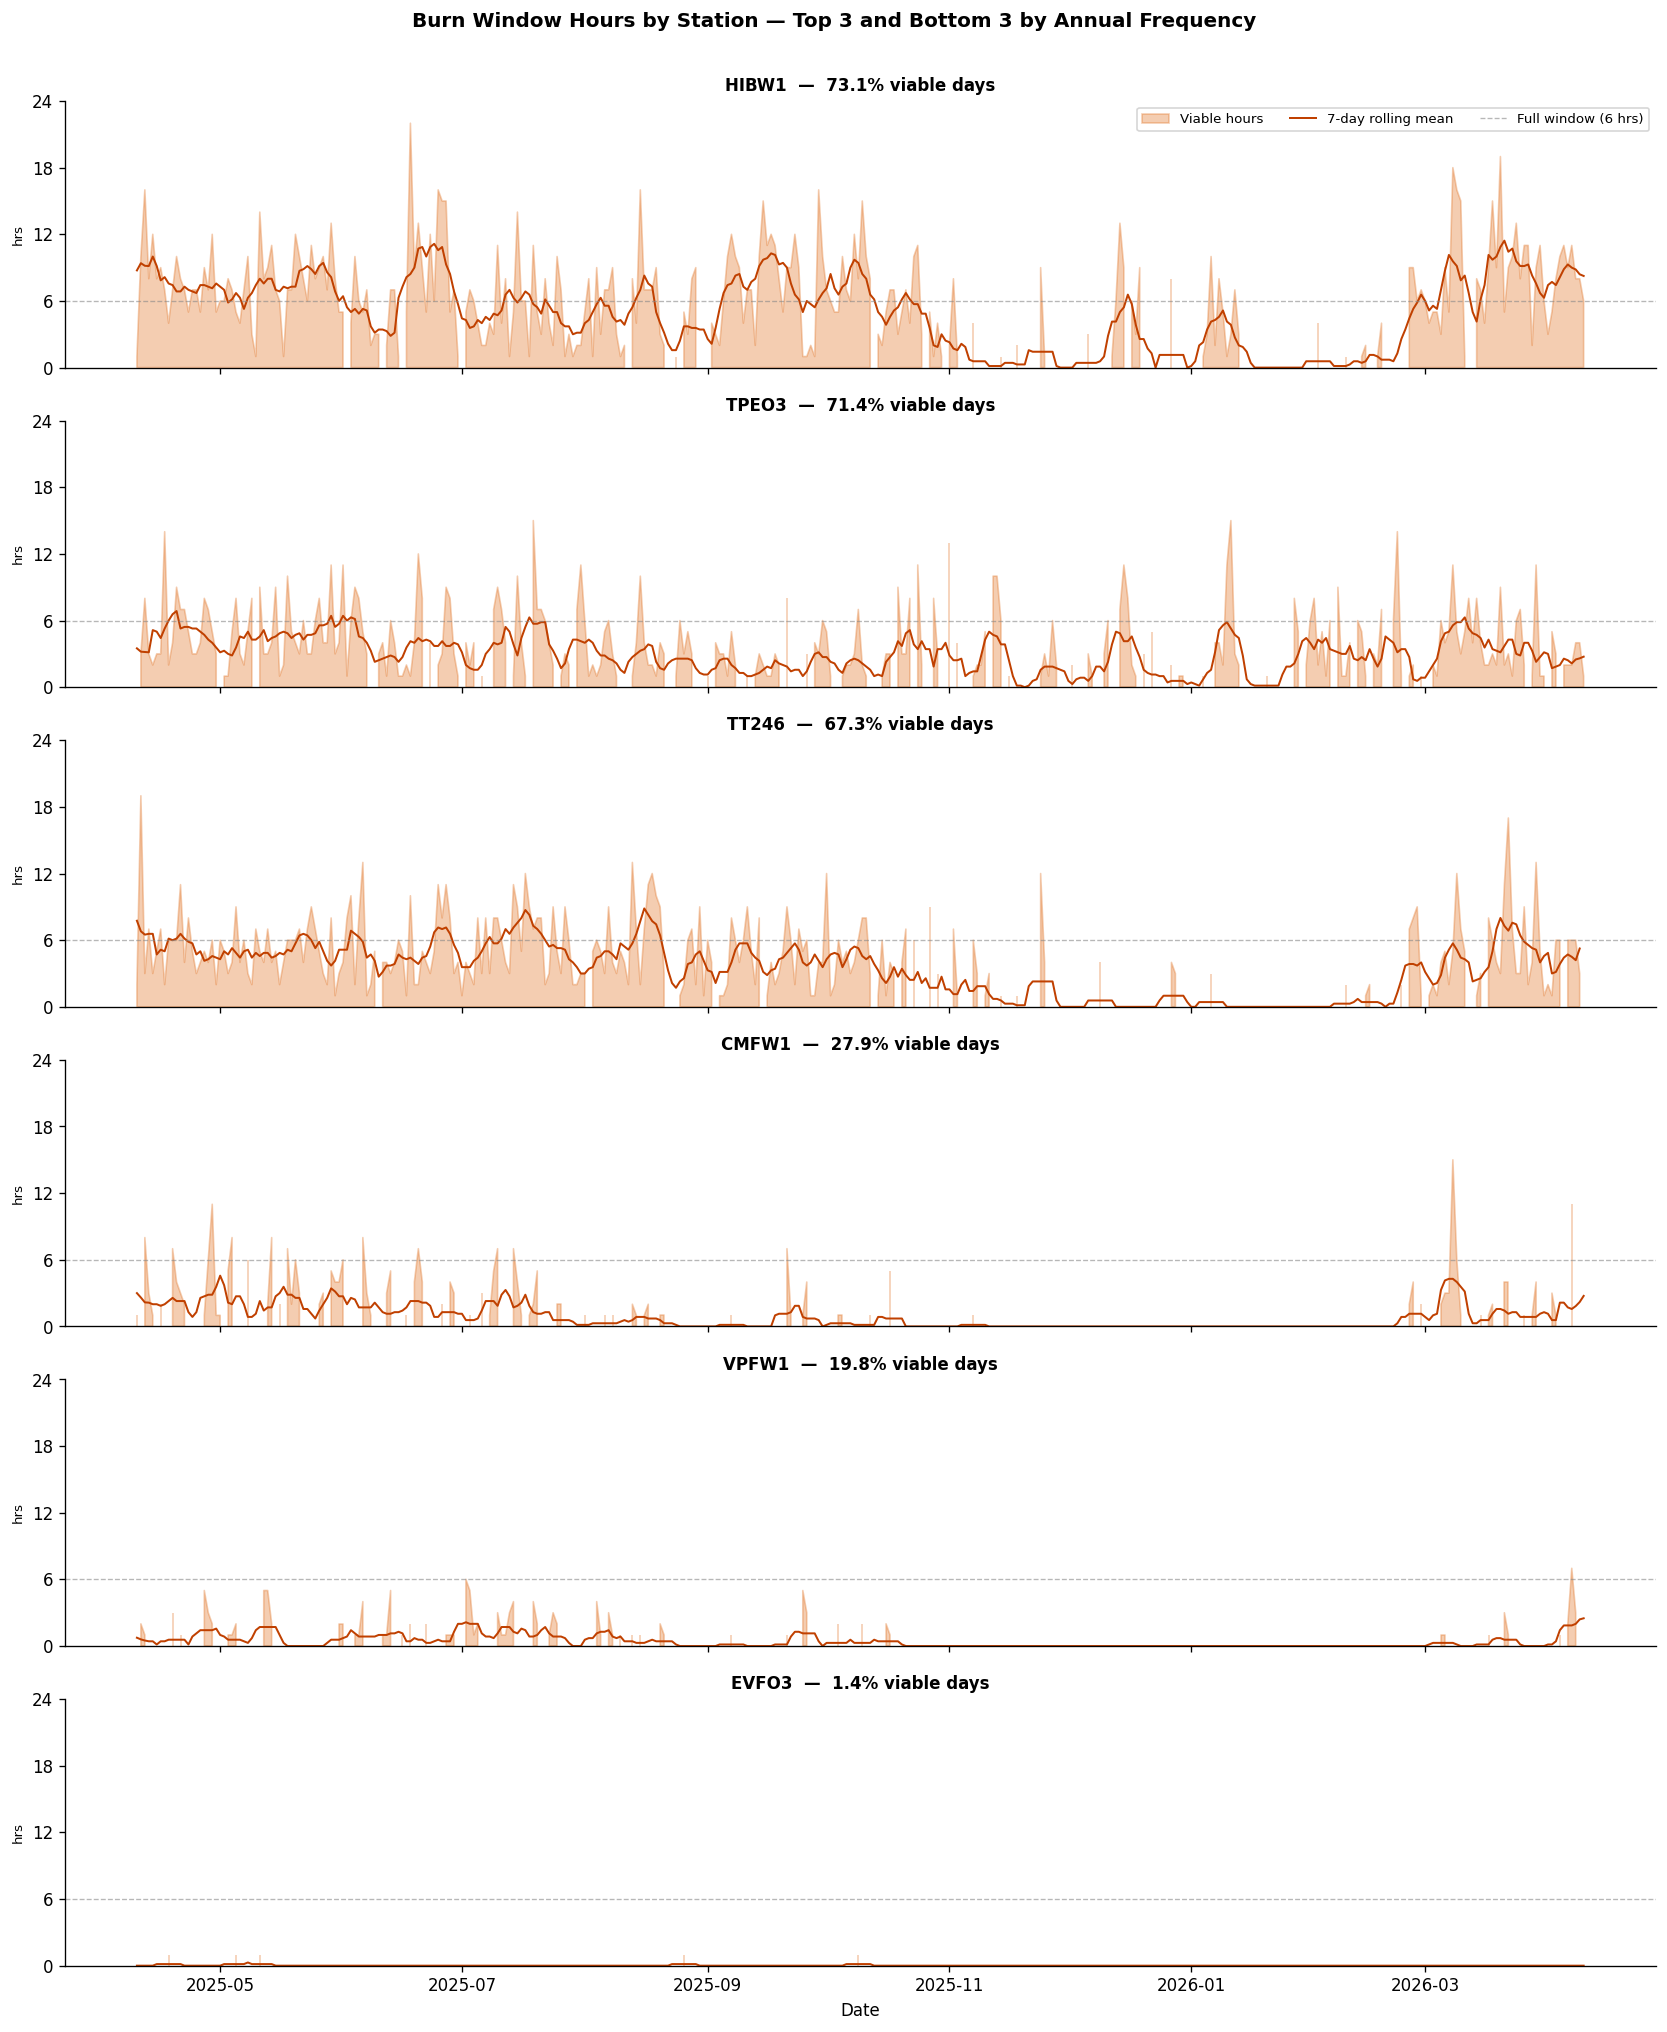

In [52]:
# Pick the top-3 and bottom-3 stations by annual viable days for contrast
top3    = annual.head(3)['station_id'].tolist()
bottom3 = annual.tail(3)['station_id'].tolist()
showcase = top3 + bottom3

fig, axes = plt.subplots(len(showcase), 1, figsize=(14, 2.8 * len(showcase)), sharex=True)

for ax, station_id in zip(axes, showcase):
    sub = daily[daily['station_id'] == station_id].sort_values('date')

    # rolling 7-day mean of window hours for smoother signal
    sub = sub.copy()
    sub['rolling_hrs'] = sub['burn_window_hours'].rolling(7, center=True, min_periods=1).mean()

    # shade viable days
    ax.fill_between(
        sub['date'], 0, sub['burn_window_hours'],
        where=sub['any_window'],
        color='#e07020', alpha=0.35, label='Viable hours'
    )
    ax.plot(sub['date'], sub['rolling_hrs'], color='#c04000', lw=1.2, label='7-day rolling mean')

    # full-window threshold line
    ax.axhline(6, color='#888', lw=0.8, ls='--', alpha=0.6, label='Full window (6 hrs)')

    # annual viable %
    pct = annual.loc[annual['station_id'] == station_id, 'pct_viable_days'].values
    pct_label = f"{pct[0]:.1f}% viable days" if len(pct) else ''
    ax.set_ylabel('hrs', fontsize=8)
    ax.set_title(f'{station_id}  —  {pct_label}', fontweight='bold', fontsize=10)
    ax.set_ylim(0, 24)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(6))

axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[-1].set_xlabel('Date')
fig.suptitle('Burn Window Hours by Station — Top 3 and Bottom 3 by Annual Frequency',
             fontweight='bold', y=1.005, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_timeseries_showcase.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 8 · Multi-Day Window Clusters
**Q: Are there consistent multi-day window clusters?**

Multi-day windows matter operationally: single-day windows may not be worth mobilizing crews. Clusters of 2+ days allow smoke dispersal, re-entry, and multi-unit burns.

In [53]:
clusters = find_window_clusters(daily, min_consecutive=2, quality_threshold='partial')
clusters.to_csv(OUT_DIR / 'window_clusters.csv', index=False)

print(f'Total multi-day clusters (≥2 consecutive partial+ days): {len(clusters)}')
print(f'Mean cluster length: {clusters["length_days"].mean():.1f} days')
print(f'Longest cluster: {clusters["length_days"].max()} days')
print(f'\nClusters by month:')
print(clusters.groupby('month')['cluster_id'].count().rename('cluster_count'))

Total multi-day clusters (≥2 consecutive partial+ days): 349
Mean cluster length: 4.6 days
Longest cluster: 61 days

Clusters by month:
month
1     18
2     14
3     35
4     46
5     48
6     39
7     41
8     34
9     30
10    24
11     7
12    13
Name: cluster_count, dtype: int64


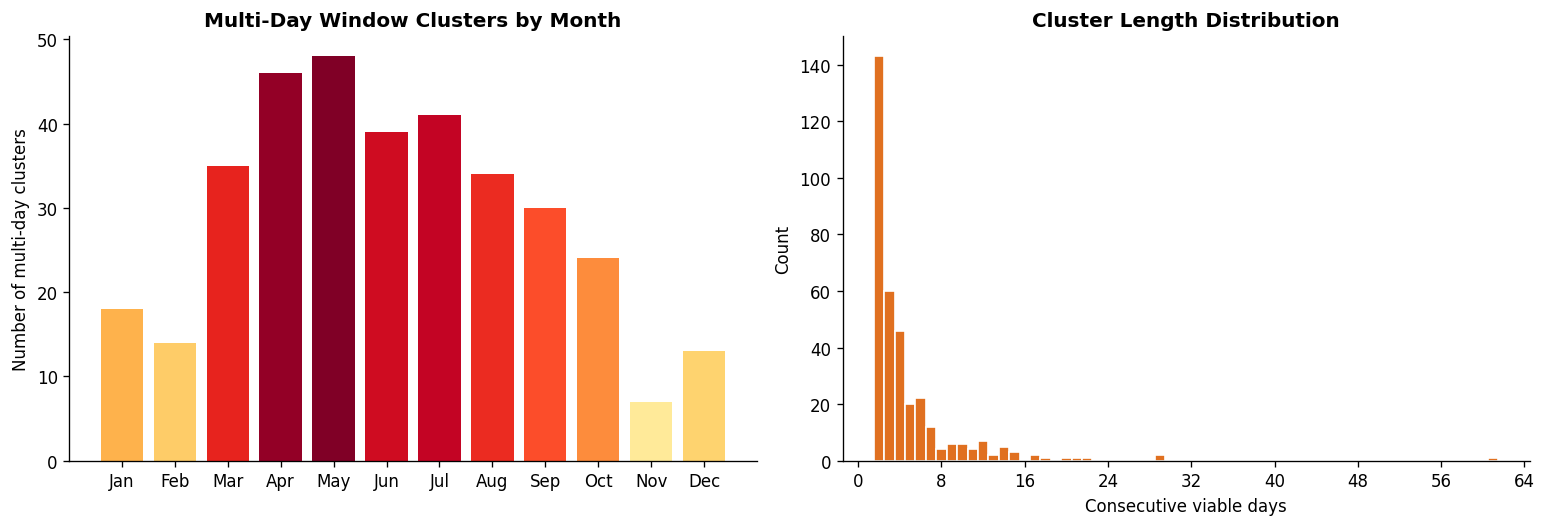

In [54]:
# Cluster frequency by month and length
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: cluster count by month
monthly_clusters = clusters.groupby('month').size().reset_index(name='cluster_count')
month_names_list = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = plt.cm.YlOrRd(monthly_clusters['cluster_count'] / monthly_clusters['cluster_count'].max())
axes[0].bar(monthly_clusters['month'], monthly_clusters['cluster_count'], color=bar_colors)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names_list)
axes[0].set_ylabel('Number of multi-day clusters')
axes[0].set_title('Multi-Day Window Clusters by Month', fontweight='bold')

# right: cluster length distribution
axes[1].hist(clusters['length_days'], bins=range(2, clusters['length_days'].max() + 2),
             color='#e07020', edgecolor='white', align='left')
axes[1].set_xlabel('Consecutive viable days')
axes[1].set_ylabel('Count')
axes[1].set_title('Cluster Length Distribution', fontweight='bold')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_window_clusters.png', bbox_inches='tight')
plt.show()

---
## 9 · Week 2 Summary Findings

*(Fill in after running with real data — template below)*

In [55]:
# Auto-generate key findings from the computed tables

best_station  = annual.iloc[0]
worst_station = annual.iloc[-1]
peak_month_net = net_monthly.loc[net_monthly['pct_viable'].idxmax(), 'month']
peak_month_name = month_names_list[peak_month_net - 1]
high_var_weeks = variation.nlargest(3, 'range_pct')['week_of_year'].tolist()
longest_cluster = clusters['length_days'].max() if len(clusters) else 0

print("="*60)
print("WEEK 2 KEY FINDINGS")
print("="*60)
print(f"\n1. Station with most viable burn days/year:")
print(f"   {best_station['station_id']} — {best_station['viable_days']} viable days "
      f"({best_station['pct_viable_days']:.1f}%), peak month: {best_station['peak_month']}")

print(f"\n2. Station with fewest viable burn days/year:")
print(f"   {worst_station['station_id']} — {worst_station['viable_days']} viable days "
      f"({worst_station['pct_viable_days']:.1f}%)")

print(f"\n3. Peak network-wide burn month: {peak_month_name}")
print(f"   ({net_monthly['pct_viable'].max():.1f}% of station-days network-wide)")

print(f"\n4. Highest inter-station variation: weeks {high_var_weeks}")
print(f"   → Weeks where local factors dominate (elevation, terrain, proximity to Cascades)")

print(f"\n5. Multi-day clusters (≥2 consecutive partial+ days):")
print(f"   {len(clusters)} clusters found, longest = {longest_cluster} days")
if len(clusters):
    top_cluster_month = clusters.groupby('month').size().idxmax()
    print(f"   Peak cluster month: {month_names_list[top_cluster_month - 1]}")

WEEK 2 KEY FINDINGS

1. Station with most viable burn days/year:
   HIBW1 — 266 viable days (73.1%), peak month: May

2. Station with fewest viable burn days/year:
   EVFO3 — 5 viable days (1.4%)

3. Peak network-wide burn month: Jul
   (69.0% of station-days network-wide)

4. Highest inter-station variation: weeks [2, 4, 10]
   → Weeks where local factors dominate (elevation, terrain, proximity to Cascades)

5. Multi-day clusters (≥2 consecutive partial+ days):
   349 clusters found, longest = 61 days
   Peak cluster month: May


---
## 10 · Files Saved

All outputs written to `data/processed/raws/`:

| File | Contents | Used by |
|---|---|---|
| `daily_windows.csv` | Daily burn window scores, all stations | Week 3, Dashboard |
| `climatology_monthly.csv` | Station × month frequency table | Dashboard |
| `climatology_weekly.csv` | Station × week frequency table | Dashboard |
| `climatology_seasonal.csv` | Station × season summary | Dashboard |
| `station_annual_summary.csv` | Per-station annual stats | Dashboard |
| `peak_season_by_station.csv` | Peak 4-week window period | Dashboard |
| `window_clusters.csv` | Multi-day consecutive window events | Week 3, Dashboard |
| `fig_*.png` | All visualizations | README, fellowship app |